# 📝 Week 4: Implementasi TF-IDF dari Scratch (Wittline)

Notebook ini mendemonstrasikan penghitungan TF-IDF **secara manual** menggunakan class `TFIDF` dari `TFIDF.py` (Wittline) pada subset 100 review dari `cleandata.csv`.

## Tujuan Pembelajaran:
1. Memahami implementasi **TF, DF, IDF, TF-IDF** step-by-step
2. Menjalankan pipeline TF-IDF manual menggunakan class `TFIDF` (Wittline)
3. Memvisualisasikan **top terms** berdasarkan rata-rata TF-IDF score

---

## 1️⃣ Import Libraries & Load Data

Import class `TFIDF` dan ambil sample 100 review dari dataset.

In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Tambahkan path folder Week 4 agar bisa import TFIDF.py
sys.path.insert(0, '.')
from TFIDF import TFIDF

print("✅ Class TFIDF berhasil diimport!")

✅ Class TFIDF berhasil diimport!


In [8]:
# Load dataset dan filter seperti Tugas 1
df = pd.read_csv("../Week 3/cleandata.csv")
df_sentiment = df[df['score'] != 3].copy()
df_sentiment = df_sentiment.dropna(subset=['text_final'])
df_sentiment = df_sentiment[df_sentiment['text_final'].str.strip() != '']

# Sample 100 review untuk demo
sample_reviews = df_sentiment['text_final'].head(100).tolist()

# Inisialisasi object TFIDF
tfidf_obj = TFIDF(sample_reviews)

print(f"Jumlah review: {len(sample_reviews)}")
print(f"\nSample review pertama:")
print(f"  '{sample_reviews[0][:100]}...'")

Jumlah review: 100

Sample review pertama:
  'kali kartu kredit cocok anak muda update alam pakai kartu terima kasih bimbing sangat baik...'


---

## 2️⃣ Preprocessing & Term Frequency (TF)

Class `TFIDF` akan melakukan:
1. **Normalisasi** teks (lowercase, hapus tanda baca, stemming)
2. **Menghitung TF** — frekuensi kemunculan setiap term dalam setiap dokumen

In [9]:
print("Preprocessing & menghitung TF...")
tfidf_obj.preprocessing_text()
tf_matrix = tfidf_obj.tf()

print(f"\n✅ TF Matrix shape: {tf_matrix.shape}")
print(f"   → {tf_matrix.shape[0]} dokumen, {tf_matrix.shape[1]} unique terms")
print(f"\nTF Matrix (5 dokumen pertama, 10 term pertama):")
print(tf_matrix.iloc[:5, :10])

Preprocessing & menghitung TF...

✅ TF Matrix shape: (100, 221)
   → 100 dokumen, 221 unique terms

TF Matrix (5 dokumen pertama, 10 term pertama):
   kali  kartu  kredit  cocok  anak  muda  update  alam  pakai  terima
0     1      2       1      1     1     1       1     1      1       1
1     0      0       0      0     0     0       0     0      0       1
2     0      0       0      0     0     0       0     0      0       0
3     0      0       0      0     0     0       0     0      0       0
4     0      0       0      0     0     0       0     0      0       0


---

## 3️⃣ Document Frequency (DF) & Inverse Document Frequency (IDF)

- **DF**: Berapa banyak dokumen yang mengandung term tertentu
- **IDF**: $\log\left(\frac{N}{DF}\right)$ — semakin jarang term muncul di dokumen, semakin tinggi IDF-nya

In [10]:
df_freq = tfidf_obj.df(tf_matrix)
print(f"DF vector shape: {df_freq.shape}")
print(f"DF (10 term pertama): {df_freq[:10]}")

print("\n" + "-" * 60)

idf_vector, idf_diag = tfidf_obj.idf(df_freq)
print(f"\nIDF vector shape: {idf_vector.shape}")
print(f"IDF values (10 term pertama): {idf_vector[:10]}")
print(f"\nIDF diagonal matrix shape: {idf_diag.shape}")

DF vector shape: (221,)
DF (10 term pertama): [ 2 16 12  3  2  2  2  2  5 33]

------------------------------------------------------------

IDF vector shape: (221,)
IDF values (10 term pertama): [4.92197334 2.84253179 3.13021387 4.51650823 4.92197334 4.92197334
 4.92197334 4.92197334 4.0056826  2.11861296]

IDF diagonal matrix shape: (221, 221)


---

## 4️⃣ TF-IDF Matrix

$$\text{TF-IDF} = \text{TF} \times \text{IDF}$$

Hasilnya di-**L2 normalize** agar setiap dokumen memiliki panjang vektor = 1.

In [11]:
tfidf_matrix = tfidf_obj.tfidf(tf_matrix, idf_vector)

print(f"✅ TF-IDF Matrix shape: {tfidf_matrix.shape}")
print(f"   → {tfidf_matrix.shape[0]} dokumen, {tfidf_matrix.shape[1]} terms")

# Tampilkan top terms berdasarkan rata-rata TF-IDF
mean_tfidf = np.mean(tfidf_matrix, axis=0)
# Convert to 1D array if matrix
mean_tfidf = np.asarray(mean_tfidf).flatten()
vocab = list(tf_matrix.columns)
top_indices = np.argsort(mean_tfidf)[::-1][:20]

print(f"\nTop 20 terms berdasarkan rata-rata TF-IDF:")
print("=" * 50)
for i, idx in enumerate(top_indices, 1):
    print(f"  {i:2d}. {vocab[idx]:20s}  TF-IDF: {mean_tfidf[idx]:.6f}")

✅ TF-IDF Matrix shape: (100, 221)
   → 100 dokumen, 221 terms

Top 20 terms berdasarkan rata-rata TF-IDF:
   1. baik                  TF-IDF: 0.104981
   2. kasih                 TF-IDF: 0.093582
   3. terima                TF-IDF: 0.091622
   4. jelas                 TF-IDF: 0.078581
   5. sangat                TF-IDF: 0.069077
   6. mudah                 TF-IDF: 0.061776
   7. cs                    TF-IDF: 0.061011
   8. bantu                 TF-IDF: 0.057448
   9. bagus                 TF-IDF: 0.052924
  10. cepat                 TF-IDF: 0.046374
  11. ramah                 TF-IDF: 0.046170
  12. kartu                 TF-IDF: 0.041652
  13. layan                 TF-IDF: 0.036583
  14. limit                 TF-IDF: 0.034470
  15. mantap                TF-IDF: 0.031233
  16. kredit                TF-IDF: 0.029543
  17. tidak                 TF-IDF: 0.028214
  18. call                  TF-IDF: 0.027411
  19. paham                 TF-IDF: 0.027032
  20. informasi             TF-IDF: 0.0

---

## 5️⃣ Visualisasi Top Terms

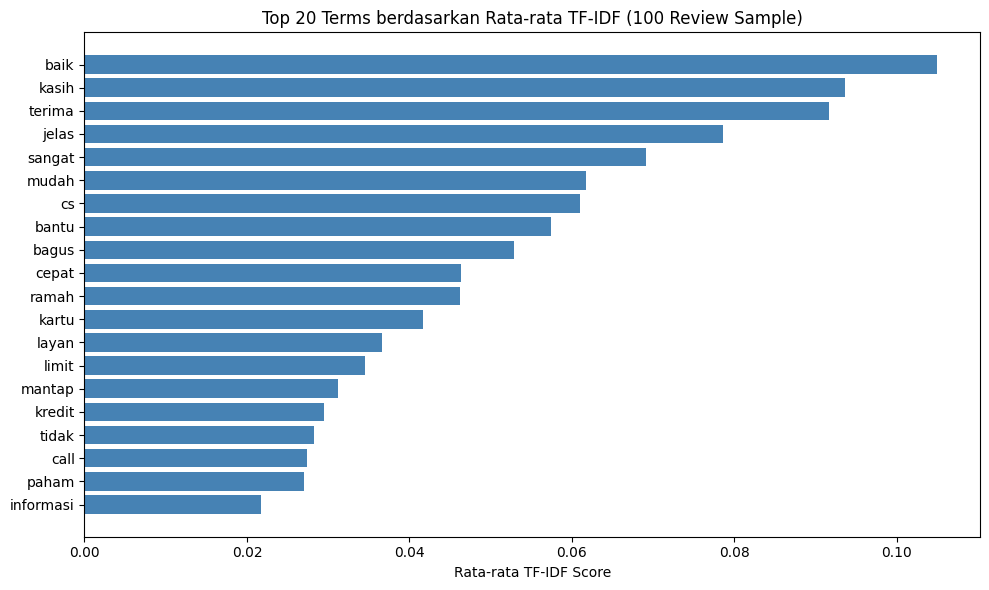

✅ Visualisasi selesai!


In [12]:
top_words = [vocab[idx] for idx in top_indices]
top_scores = [mean_tfidf[idx] for idx in top_indices]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top_words)), top_scores, color='steelblue')
ax.set_yticks(range(len(top_words)))
ax.set_yticklabels(top_words)
ax.invert_yaxis()
ax.set_xlabel('Rata-rata TF-IDF Score')
ax.set_title('Top 20 Terms berdasarkan Rata-rata TF-IDF (100 Review Sample)')
plt.tight_layout()
plt.show()
print("✅ Visualisasi selesai!")

---

## 📝 Kesimpulan

### 🎯 Poin Penting:

1. **Implementasi Manual**: Class `TFIDF` dari Wittline berhasil menghitung TF, DF, IDF, dan TF-IDF matrix secara step-by-step.

2. **Pipeline TF-IDF Manual**:
   - `preprocessing_text()` → normalisasi & tokenisasi
   - `tf()` → matrix (N×V) frekuensi term per dokumen
   - `df()` → vektor (V,) jumlah dokumen per term
   - `idf()` → matrix diagonal (V×V)
   - `tfidf()` → matrix (N×V) L2-normalized

3. **Top Terms**: Kata-kata seperti *baik*, *kasih*, *terima*, *jelas*, *sangat* mendominasi, mencerminkan review positif yang mendominasi dataset.

### 📚 Referensi

1. [Wittline/tf-idf](https://github.com/Wittline/tf-idf)

---